# Chain

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

- Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
- Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
- [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
- [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes

<img width="500" src="https://camo.githubusercontent.com/b5c785d68a6865bf441b68005e8e13709495c8c9c82ee7913a8888705ac2ee24/68747470733a2f2f63646e2e70726f642e776562736974652d66696c65732e636f6d2f3635623863643732383335636565616364343434396135332f3636646261623038646436303762303864663565313130315f636861696e312e706e67" />

## Messages

Chat models can use **messages**, which capture different roles within a conversation.

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Each message can be supplied with a few things:
- **content -** content of the message
- **name -** optionally, a message author
- **response_metadata -** optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [1]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage

messages = []

messages.append( AIMessage(content="So you said you were researching ocean mammals?", name="Model") )
messages.append( HumanMessage(content="Yes, that's right.", name="Dibyajyoti") )
messages.append( AIMessage(content="Great, what would you like to learn about.", name="Model") )
messages.append( HumanMessage(content="I want to learn about the best place to see Orcas in the US.", name="Dibyajyoti") )

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Dibyajyoti

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Dibyajyoti

I want to learn about the best place to see Orcas in the US.


## Chat Model

In [2]:
import dotenv

dotenv.load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

gemini_25_fl = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)

result = gemini_25_fl.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [4]:
result

AIMessage(content="That's a fantastic question! When it comes to seeing Orcas (also known as killer whales) in the United States, there's one standout location that consistently offers the best opportunities:\n\n**The San Juan Islands, Washington**\n\nHere's why the San Juan Islands are the top choice:\n\n*   **Resident Orca Populations:** The San Juan Islands are home to several pods of **Southern Resident Orcas**. These are distinct populations that have specific migration patterns and feeding grounds. They are often seen in these waters from **late spring through early fall (roughly May to October)**.\n*   **Abundant Prey:** The waters around the San Juans are rich in Chinook salmon, which are the primary food source for the Southern Resident Orcas. This abundance of food keeps them returning to the area.\n*   **Accessibility:** The islands are relatively accessible by ferry from the mainland of Washington state.\n*   **Dedicated Whale Watching Tours:** Numerous reputable whale watc

In [5]:
result.response_metadata

{'finish_reason': 'STOP',
 'model_name': 'gemini-2.5-flash-lite',
 'safety_ratings': [],
 'model_provider': 'google_genai'}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language.

When we bind an API, for example, as a tool we given the model awareness of the required input schema. The model will choose to call a tool based upon the natural language input from the user. And, it will return an output that adheres to the tool's schema.

<img width="800" src="https://camo.githubusercontent.com/44ec57bfbf7f440b6ee88e4d3123c5fddbaa1f3c476f7b56eeaed87254284308/68747470733a2f2f63646e2e70726f642e776562736974652d66696c65732e636f6d2f3635623863643732383335636565616364343434396135332f3636646261623038646331633137613761353766393936305f636861696e322e706e67" />

In [6]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

gemini_25_fl_with_tools = gemini_25_fl.bind_tools([multiply])

If we pass an input - e.g., "What is 2 multiplied by 3" - we see a tool call returned.

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}

In [7]:
tool_call = gemini_25_fl_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [8]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '5b525034-03c8-49c4-826e-bbdf2ebd4e59',
  'type': 'tool_call'}]

In [9]:
tool_call

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019db70f-9476-7ac0-aebe-a87c56aed79f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '5b525034-03c8-49c4-826e-bbdf2ebd4e59', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 57, 'output_tokens': 18, 'total_tokens': 75, 'input_token_details': {'cache_read': 0}})

## Using messages as state

In [10]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessageState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem!

As we discussed, each node will **return a new value** for our state key `messages`. But, this new value will **overwrite** the prior `messages` value!

As our graph runs, we want to **append** messages to our `messages` state key. We can use [reducer functions](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers) to address this.

Reducers specify **how state updates** are performed. If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before. But, to append messages, we can use the **pre-built** `add_messages` reducer. This ensures that any messages are appended to the existing list of `messages`.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [11]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class MessageState(TypedDict):
    message: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built `MessagesState`! MessagesState is defined:

- With a pre-build single `messages` key
- This is a list of `AnyMessage` objects
- It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is **less verbose** than defining a custom `TypedDict`, as shown above.

In [12]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the add_messages reducer works in isolation.

In [13]:
from langchain_core.messages import HumanMessage, AIMessage

# Initial state
initial_messages = [
    AIMessage(content="Hello! How can I assist you?", name="Model"),
    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='c927f7a3-bdcb-4581-849c-85096bc3feaf', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='17df29bd-78e2-4a27-a4d3-cd7451a06819'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='f3cc9382-3975-49b8-8345-bc51c86710c8', tool_calls=[], invalid_tool_calls=[])]

## Our graph

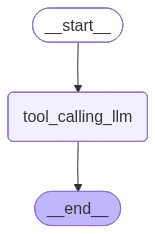

In [14]:
from IPython.display import Image, display
from langgraph.graph import MessagesState, StateGraph, START, END

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [gemini_25_fl_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds **without** any tool calls.

In [15]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I help you today?


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [16]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (23884302-b398-4c3e-a98a-3c6f71bfa970)
 Call ID: 23884302-b398-4c3e-a98a-3c6f71bfa970
  Args:
    a: 2
    b: 3
